# Work NRLMF in Python

In [1]:
from scipy.special import expit

In [2]:
import numpy as np

random_state = np.random.RandomState(0x0BADCAFE)

Setup for paths and names

In [3]:
import os
import time

PATH_TO_EXP = "/Users/sijianfan/Documents/projects/BiSSGL/datasets/simulations"
PATH_DATA = os.path.join(PATH_TO_EXP, "n_features")

PATH_ARCHIVE = os.path.join(PATH_DATA, "arch_bissgl")
if not os.path.isdir(PATH_ARCHIVE):
    os.mkdir(PATH_ARCHIVE)

filenames = {"input": "data_{}.gz", "output": "results_bissgl.gz"}

filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_DATA, filenames["output"])

if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

In [4]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        "train_size": [0.02],
        "n_features": np.arange(50, 401, 50),
        "n_splits": [5],
    }
)

grid_model = ParameterGrid(
    {
        "C_lasso": [0.0],
        "C_group": [0.0],
        "C_ridge": [1e0],
        "lamb": [1e-4, 1e-3, 1e-2],
        "rank": [25],
    }
)

Use `i = 0` as an example

In [37]:
i = 0
par_mdl = grid_model[0]
par_dtst = grid_dataset[0]

In [38]:
from sgimc.utils import mc_split
from sgimc.utils import get_submatrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# from scipy.sparse import coo_matrix


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }

In [39]:
from sgimc.utils import load, save
from sklearn.model_selection import train_test_split

X, Y, R_full, R_noisy = load(filename_input.format(i))
dvlp_size, test_size = 0.9, 0.1
ind_dvlp, ind_test = next(
    mc_split(
        R_full,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)
R_test = get_submatrix(R_full, ind_test)
# prepare the train dataset: take the specified share from the beginnig of the index array
ind_train_all, _ = train_test_split(
    ind_dvlp,
    shuffle=False,
    random_state=random_state,
    test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
)

print(f"R_noisy: {np.unique(R_noisy)}")
print(f"R_full: {np.unique(R_full)}")

R_noisy: [-1.  1.]
R_full: [-1.  1.]


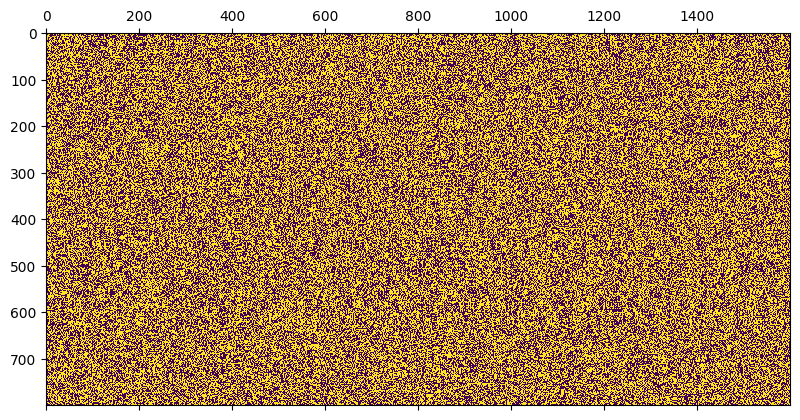

In [40]:
import matplotlib.pyplot as plt

plt.matshow(R_noisy)

In [56]:
from scipy.sparse import coo_matrix

R_train: [-1.  0.  1.]


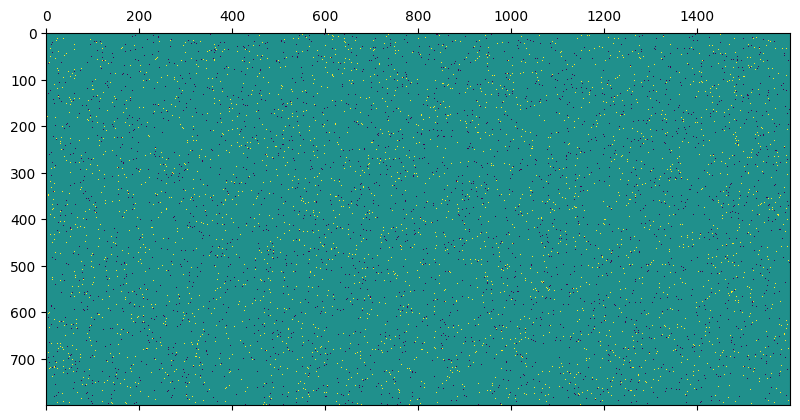

In [64]:
# option 1: (separate missing and negative values)
R_train = get_submatrix(R_noisy, ind_train_all)
R_train = R_train.toarray()
plt.matshow(R_train)
print(f"R_train: {np.unique(R_train)}")
R_train = coo_matrix(R_train).tocsr()

R_train after replacement: [-1.  1.]


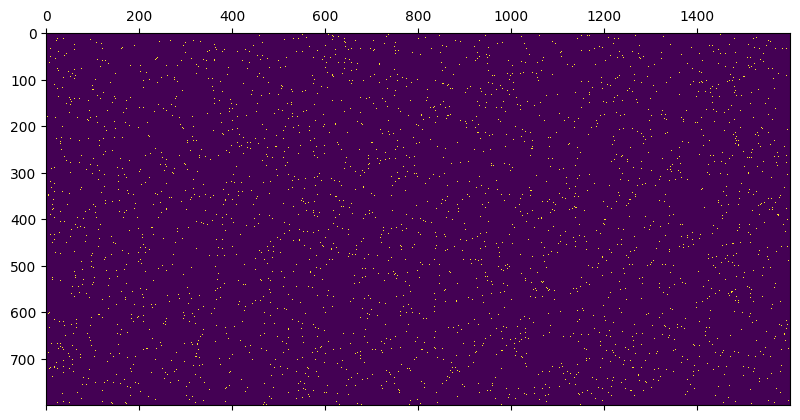

In [65]:
# option 2: (mixed missing and negative values)
R_train = get_submatrix(R_noisy, ind_train_all)
R_train = R_train.toarray()
R_train[R_train == 0] = -1
plt.matshow(R_train)
print(f"R_train after replacement: {np.unique(R_train)}")
R_train = coo_matrix(R_train).tocsr()

In [59]:
from sgimc import SparseGroupIMCClassifier

In [60]:
print(C_lasso, C_group, C_ridge)

0.0 0.0 1.0


In [ ]:
# set up the model
C_lasso, C_group, C_ridge = (
    par_mdl["C_lasso"],
    par_mdl["C_group"],
    par_mdl["C_ridge"],
)
lamb = par_mdl["lamb"]
imc = SparseGroupIMCClassifier(
    par_mdl["rank"],
    n_threads=4,
    random_state=42,
    C_lasso=C_lasso,
    C_group=C_group,
    C_ridge=C_ridge,
)

# fit on the whole development dataset
imc.fit(X, Y, R_train, sample_weight=np.ones(R_train.nnz) / lamb)

# get the score
prob_full = imc.predict_proba(X, Y)
prob_test = get_submatrix(prob_full, ind_test)
scores_test = mc_get_scores(R_test, prob_test)

In [68]:
print(scores_test)

{'tn': 41903, 'fn': 23877, 'fp': 22025, 'tp': 40195, 'auc': 0.6517407701719122}


In [66]:
print(np.unique(R_train.toarray()))

[-1.  1.]


<StemContainer object of 3 artists>

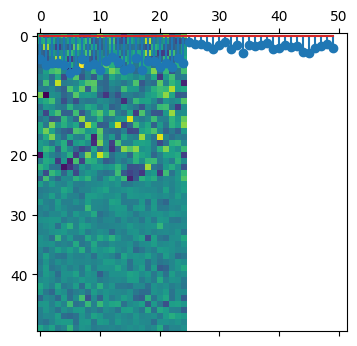

In [ ]:
plt.matshow(imc.coef_H_)

<StemContainer object of 3 artists>

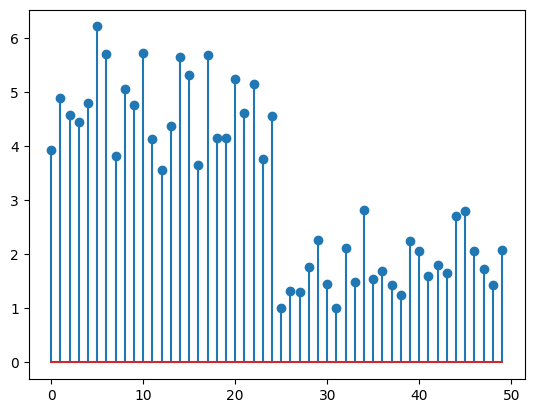

In [75]:
plt.stem(abs(imc.coef_H_).max(axis=1))

In [76]:
imc.coef_H_.shape

(50, 25)